In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mode as scipy_mode

# Load data
chapters_df = pd.read_csv('/content/drive/MyDrive/DS-assignment/chapters.csv')
interactions_df = pd.read_csv('/content/drive/MyDrive/DS-assignment/interactions.csv')

# Basic preview
print("Chapters shape:", chapters_df.shape)
print("Interactions shape:", interactions_df.shape)

Chapters shape: (50000, 6)
Interactions shape: (1000000, 3)


In [ ]:
temp_df=pd.DataFrame()

In [ ]:
# Split tags on pipe, take first 4, pad with None if fewer than 4
for i in range(1, 5):
    chapters_df[f'cat{i}'] = chapters_df['tags'].apply(
        lambda x: x.split('|')[i-1] if  len(x.split('|')) >= i else None
    )
# Verify
print(chapters_df[['tags', 'cat1', 'cat2', 'cat3', 'cat4']].head(10))
print("\nNull counts per cat:")
print(chapters_df[['cat1','cat2','cat3','cat4']].isnull().sum())

                                       tags              cat1  \
0                            Fantasy|Horror           Fantasy   
1      Fantasy|Young Adult|Literary Fiction           Fantasy   
2                                   Fantasy           Fantasy   
3                  Literary Fiction|Fantasy  Literary Fiction   
4  Horror|Young Adult|Romance|Graphic Novel            Horror   
5          Young Adult|Paranormal|Dystopian       Young Adult   
6                               Young Adult       Young Adult   
7              Literary Fiction|Young Adult  Literary Fiction   
8            Literary Fiction|Graphic Novel  Literary Fiction   
9                Dystopian|Literary Fiction         Dystopian   

               cat2              cat3           cat4  
0            Horror              None           None  
1       Young Adult  Literary Fiction           None  
2              None              None           None  
3           Fantasy              None           None  
4       Y

#book aggeregation

create df to get book level data such as no of chapters,categories & author

In [ ]:
# --- Mode helper (handles ties by taking first) ---
def safe_mode(series):
    # We take the first mode in case of ties.
    if series.empty or series.isnull().all():
        return None
    return series.mode()[0]

# book aggregation
book_meta = chapters_df.groupby('book_id').agg(
    total_chapters   = ('chapter_id', 'count'),
    author_id        = ('author_id', safe_mode),
    book_cat1        = ('cat1', safe_mode),
    book_cat2        = ('cat2', safe_mode),
    book_cat3        = ('cat3', safe_mode),
    book_cat4        = ('cat4', safe_mode),
).reset_index()

print("Book meta shape:", book_meta.shape)
print(book_meta.head())

Book meta shape: (9575, 7)
   book_id  total_chapters  author_id  book_cat1        book_cat2  book_cat3  \
0   100089               3      55121    Fantasy  Science Fiction       None   
1   100096               1      61876    Romance             None       None   
2   100193               4      67983   Thriller         Thriller    Mystery   
3   100205               4      64099  Adventure        Adventure  Adventure   
4   100301               3      77538      Humor        Dystopian       None   

          book_cat4  
0              None  
1              None  
2         Dystopian  
3  Literary Fiction  
4              None  


use this df to make user centric data story

In [ ]:
# Count chapters read per user per book
user_book_reads = (
    interactions_df
    .groupby(['user_id', 'book_id'])['chapter_id']
    .count()
    .reset_index()
    .rename(columns={'chapter_id': 'chapters_read'})
)

user_book_reads.head()


,user_id,book_id,chapters_read
0,user_0000013,200976,1
1,user_0000013,461083,1
2,user_0000013,469844,1
3,user_0000013,635456,1
4,user_0000013,878246,1


In [ ]:
# Join total chapters
user_book_reads = user_book_reads.merge(
    book_meta[['book_id', 'total_chapters']], on='book_id', how='left'
)

user_book_reads.head()

,user_id,book_id,chapters_read,total_chapters
0,user_0000013,200976,1,8
1,user_0000013,461083,1,8
2,user_0000013,469844,1,2
3,user_0000013,635456,1,8
4,user_0000013,878246,1,9


In [ ]:
# Read percentage
user_book_reads['read_pct'] = (
    user_book_reads['chapters_read'] / user_book_reads['total_chapters']
)

# Classify
user_book_reads['status'] = pd.cut(
    user_book_reads['read_pct'],
    bins=[-0.01, 0.0, 0.20, 0.90, 1.01],
    labels=['none', 'early', 'in_progress', 'completed']
)

print(user_book_reads['status'].value_counts())
print(user_book_reads.head())

status
early          711299
in_progress    268751
completed       19470
none                0
Name: count, dtype: int64
        user_id  book_id  chapters_read  total_chapters  read_pct       status
0  user_0000013   200976              1               8  0.125000        early
1  user_0000013   461083              1               8  0.125000        early
2  user_0000013   469844              1               2  0.500000  in_progress
3  user_0000013   635456              1               8  0.125000        early
4  user_0000013   878246              1               9  0.111111        early


#continue reading segment

In [ ]:
# Find oyut in_progress books per user
continue_reading = (
    user_book_reads[user_book_reads['status'] == 'in_progress']
    [['user_id', 'book_id', 'read_pct']]
    .sort_values(['user_id', 'read_pct'], ascending=[True, False])  # userwise having largest reading left
)

# For lookup: dict of user_id -> list of book_ids
continue_reading_dict = (
    continue_reading
    .groupby('user_id')['book_id']
    .apply(list)
    .to_dict()
)

print("Users with continue reading:", len(continue_reading_dict))
print("Sample:", dict(list(continue_reading_dict.items())[:2]))

Users with continue reading: 124891
Sample: {'user_0000013': [469844, 976042], 'user_0000177': [902903]}


For improvement this section can be broken in two parts

a. Continue Reading- if sequential reading is left

b. Complete to get rewards- if in between chapters are left

#feature engineering

In [ ]:
# users who started a read
user_started = user_book_reads[user_book_reads['read_pct'] > 0]
# users who successfully completed the read
user_completed = user_book_reads[user_book_reads['status'] == 'completed']
# users who havent completed the reading
#Assumption in_process= left as there is no time or engagement data availalbr
user_left= user_book_reads[user_book_reads['status'] == 'in_progress']  # left = in_progress
#users who are in early stage of reading
user_early = user_book_reads[user_book_reads['status'] == 'early']


In [ ]:
# Feature 1 books started by each user
f_started = (
    user_started.groupby('user_id')['book_id']
    .nunique()
    .rename('total_books_started')
)
#Feature 2 books completed by each usr
f_completed = (
    user_completed.groupby('user_id')['book_id']
    .nunique()
    .rename('total_books_completed')
)



In [ ]:
#Feature 3 avg read_pct for books left in between (early + in_progress) ---
left_books = user_book_reads[user_book_reads['status'].isin(['in_progress'])]
f_avg_incomp = (
    left_books.groupby('user_id')['read_pct']
    .mean()
    .rename('avg_completion_pct_incomplete')
)

left_books.head()

,user_id,book_id,chapters_read,total_chapters,read_pct,status
2,user_0000013,469844,1,2,0.500000,in_progress
6,user_0000013,976042,1,3,0.333333,in_progress
18,user_0000177,902903,1,4,0.250000,in_progress
19,user_0000188,105621,1,3,0.333333,in_progress
21,user_0000188,489633,1,3,0.333333,in_progress


In [ ]:
#Feature 4: avg chapters read per book
f_avg_chap = (
    user_started.groupby('user_id')['chapters_read']
    .mean()
    .rename('avg_chapters_per_book')
)
f_avg_chap.head()


,avg_chapters_per_book
user_id,
user_0000013,1.0
user_0000115,1.0
user_0000177,1.0
user_0000188,1.0
user_0000257,1.0


In [ ]:
# --- Feature 5 & 6: exploration score & author diversity ---
# Need chapter-level join to get tags and author per interaction
interactions_enriched = interactions_df.merge(
    chapters_df[['chapter_id', 'author_id', 'cat1', 'cat2', 'cat3', 'cat4']],
    on='chapter_id', how='left'
)

# Exploration score: unique tags seen across cat1–cat4 per user
def count_unique_tags(df, user_col='user_id'):
    all_tags = pd.melt(
        df[[user_col, 'cat1', 'cat2', 'cat3', 'cat4']],
        id_vars=user_col, value_name='tag'
    ).dropna(subset=['tag'])
    all_tags = all_tags[all_tags['tag'] != None]
    return all_tags.groupby(user_col)['tag'].nunique().rename('exploration_score')

f_exploration = count_unique_tags(interactions_enriched)

# Author diversity: unique authors read
f_author_div = (
    interactions_enriched.groupby('user_id')['author_id']
    .nunique()
    .rename('author_diversity')
)



In [ ]:
# --- Combine all base features ---
user_features = (
    f_started
    .to_frame()
    .join(f_completed, how='left')
    .join(f_avg_incomp, how='left')
    .join(f_avg_chap, how='left')
    .join(f_exploration, how='left')
    .join(f_author_div, how='left')
    .fillna(0)
    .reset_index()
)

print("User features shape:", user_features.shape)
print(user_features.describe())

User features shape: (149803, 7)
       total_books_started  total_books_completed  \
count        149803.000000          149803.000000   
mean              6.672230               0.129971   
std               2.570475               0.360381   
min               1.000000               0.000000   
25%               5.000000               0.000000   
50%               6.000000               0.000000   
75%               8.000000               0.000000   
max              20.000000               4.000000   

       avg_completion_pct_incomplete  avg_chapters_per_book  \
count                  149803.000000          149803.000000   
mean                        0.276144               1.000490   
std                         0.140118               0.009834   
min                         0.000000               1.000000   
25%                         0.250000               1.000000   
50%                         0.291667               1.000000   
75%                         0.354167            

avg chapter per book is of no use, as its exactly almost 1 for all the users

In [ ]:
# Bin users by total_books_started
#1-2 for cold startes
#3-5 for 25%
#6-8 for 75%(maximum user base)
#9-20 for rest
user_features['read_activity_bin'] = pd.cut(
    user_features['total_books_started'],
    bins=[0, 2, 5, 8, 20],
    labels=['1-2', '3-5', '6-8', '9-20']
)

# Encode it ordinally (preserves order, low cardinality)
activity_order = {'1-2': 0, '3-5': 1, '6-8': 2, '9-20': 3}
user_features['read_activity_bin_encoded'] = (
    user_features['read_activity_bin'].map(activity_order)
)

print(user_features['read_activity_bin'].value_counts().sort_index())



read_activity_bin
1-2      5530
3-5     45918
6-8     64171
9-20    34184
Name: count, dtype: int64


In [ ]:
# cold vs build users
user_features['is_cold'] = user_features['total_books_started'] <= 2
print("\nCold users:", user_features['is_cold'].sum())
print("Developed users:", (~user_features['is_cold']).sum())


Cold users: 5530
Developed users: 144273


In [ ]:
#Join user_book_reads with book_meta to get category per book
user_book_cats = user_book_reads.merge(
    book_meta[['book_id', 'book_cat1', 'book_cat2', 'book_cat3', 'book_cat4']],
    on='book_id', how='left'
)


In [ ]:
# Completed books cat
completed_cats = user_book_cats[user_book_cats['status'] == 'completed']

completed_cats.head()

,user_id,book_id,chapters_read,total_chapters,read_pct,status,book_cat1,book_cat2,book_cat3,book_cat4
40,user_0000321,806242,1,1,1.0,completed,Romance,Graphic Novel,Dystopian,None
56,user_0000499,539963,1,1,1.0,completed,Historical Fiction,Dystopian,None,None
61,user_0000549,675402,1,1,1.0,completed,Paranormal,Science Fiction,Graphic Novel,None
245,user_0002087,107459,1,1,1.0,completed,Mystery,Dystopian,Adventure,None
296,user_0002694,646802,1,1,1.0,completed,Graphic Novel,Paranormal,Romance,None


In [ ]:
#Left books cats
left_cats = user_book_cats[user_book_cats['status'].isin(['early', 'in_progress'])]
left_cats.head()

,user_id,book_id,chapters_read,total_chapters,read_pct,status,book_cat1,book_cat2,book_cat3,book_cat4
0,user_0000013,200976,1,8,0.125000,early,Thriller,Thriller,Thriller,Graphic Novel
1,user_0000013,461083,1,8,0.125000,early,Adventure,Graphic Novel,Adventure,Adventure
2,user_0000013,469844,1,2,0.500000,in_progress,Graphic Novel,Adventure,Mystery,Humor
3,user_0000013,635456,1,8,0.125000,early,Historical Fiction,Historical Fiction,Historical Fiction,None
4,user_0000013,878246,1,9,0.111111,early,Romance,Romance,Adventure,Mystery


In [ ]:
# --- User completed and left categories (mode) ---
def mode_cats(df, user_col='user_id', prefix=''):
    result = pd.DataFrame()
    result[user_col] = df[user_col].unique()
    result = result.set_index(user_col)
    for i in range(1, 5):
        col = f'book_cat{i}'
        mode_col = (
            df[df[col] != None]          # ignore NA before taking mode
            .groupby(user_col)[col]
            .agg(safe_mode)
            .rename(f'{prefix}_mode_cat{i}')
        )
        result = result.join(mode_col, how='left')
    return result.reset_index()



In [ ]:
completed_mode = mode_cats(completed_cats, prefix='completed')
left_mode      = mode_cats(left_cats,      prefix='left')


In [ ]:
print("Completed mode:", completed_mode.head())
print("Left mode:", left_mode.head())

Completed mode:         user_id completed_mode_cat1 completed_mode_cat2 completed_mode_cat3  \
0  user_0000321             Romance       Graphic Novel           Dystopian   
1  user_0000499  Historical Fiction           Dystopian                None   
2  user_0000549          Paranormal     Science Fiction       Graphic Novel   
3  user_0002087             Mystery           Dystopian           Adventure   
4  user_0002694       Graphic Novel          Paranormal             Romance   

  completed_mode_cat4  
0                None  
1                None  
2                None  
3                None  
4                None  
Left mode:         user_id left_mode_cat1 left_mode_cat2 left_mode_cat3  \
0  user_0000013      Adventure      Adventure      Adventure   
1  user_0000115        Romance       Thriller      Adventure   
2  user_0000177      Adventure      Adventure          Crime   
3  user_0000188      Adventure      Dystopian      Adventure   
4  user_0000257      Adventure    

In [ ]:
# Join into user_features
user_features = user_features.merge(completed_mode, on='user_id', how='left')
user_features = user_features.merge(left_mode,on='user_id', how='left')

In [ ]:
user_features.head()

,user_id,total_books_started,total_books_completed,avg_completion_pct_incomplete,avg_chapters_per_book,exploration_score,author_diversity,read_activity_bin,read_activity_bin_encoded,is_cold,completed_mode_cat1,completed_mode_cat2,completed_mode_cat3,completed_mode_cat4,left_mode_cat1,left_mode_cat2,left_mode_cat3,left_mode_cat4
0,user_0000013,7,0.0,0.416667,1.0,9,7,6-8,2,False,NaN,NaN,NaN,NaN,Adventure,Adventure,Adventure,Adventure
1,user_0000115,6,0.0,0.000000,1.0,11,6,6-8,2,False,NaN,NaN,NaN,NaN,Romance,Thriller,Adventure,Adventure
2,user_0000177,6,0.0,0.250000,1.0,10,6,6-8,2,False,NaN,NaN,NaN,NaN,Adventure,Adventure,Crime,Dystopian
3,user_0000188,8,0.0,0.375000,1.0,10,8,6-8,2,False,NaN,NaN,NaN,NaN,Adventure,Dystopian,Adventure,Adventure
4,user_0000257,5,0.0,0.333333,1.0,9,5,3-5,1,False,NaN,NaN,NaN,NaN,Adventure,Adventure,Dystopian,Historical Fiction


In [ ]:
print("User features shape:", user_features.shape)
print(user_features[['user_id',
                      'completed_mode_cat1', 'completed_mode_cat2',
                      'left_mode_cat1',      'left_mode_cat2']].head(10))


User features shape: (149803, 18)
        user_id completed_mode_cat1 completed_mode_cat2 left_mode_cat1  \
0  user_0000013                 NaN                 NaN      Adventure   
1  user_0000115                 NaN                 NaN        Romance   
2  user_0000177                 NaN                 NaN      Adventure   
3  user_0000188                 NaN                 NaN      Adventure   
4  user_0000257                 NaN                 NaN      Adventure   
5  user_0000282                 NaN                 NaN      Adventure   
6  user_0000321             Romance       Graphic Novel          Crime   
7  user_0000352                 NaN                 NaN      Adventure   
8  user_0000383                 NaN                 NaN        Mystery   
9  user_0000499  Historical Fiction           Dystopian          Humor   

  left_mode_cat2  
0      Adventure  
1       Thriller  
2      Adventure  
3      Dystopian  
4      Adventure  
5          Humor  
6  Graphic Novel  

In [ ]:
# Drop sparse completed cat columns
user_features.drop(
    columns=['completed_mode_cat3', 'completed_mode_cat4'],
    inplace=True
)

In [ ]:
import numpy as np
# Check how sparse completed_mode_cat1 still is
none_pct = (user_features['completed_mode_cat1'].isna()).mean()
print(f"completed_mode_cat1 NONE %: {none_pct:.1%}")

# Check left_mode coverage
for i in range(1, 5):
    col = f'left_mode_cat{i}'
    none_cnt = (user_features[col].isna()).mean()
    print(f"{col} NONE %: {none_cnt:.1%}")

completed_mode_cat1 NONE %: 87.8%
left_mode_cat1 NONE %: 0.0%
left_mode_cat2 NONE %: 0.0%
left_mode_cat3 NONE %: 0.1%
left_mode_cat4 NONE %: 0.4%


In [ ]:
# Drop left_mode_cat4
user_features.drop(columns=['left_mode_cat4'], inplace=True)

In [ ]:
# completed_mode_cat1 → binary flag
user_features['has_completed_any'] = (
    user_features['completed_mode_cat1'].notna()
).astype(int)


print("User features shape:", user_features.shape)
print("Columns:", user_features.columns.tolist())

User features shape: (149803, 16)
Columns: ['user_id', 'total_books_started', 'total_books_completed', 'avg_completion_pct_incomplete', 'avg_chapters_per_book', 'exploration_score', 'author_diversity', 'read_activity_bin', 'read_activity_bin_encoded', 'is_cold', 'completed_mode_cat1', 'completed_mode_cat2', 'left_mode_cat1', 'left_mode_cat2', 'left_mode_cat3', 'has_completed_any']


In [ ]:
columns_to_drop = [
    'completed_mode_cat1_x', 'completed_mode_cat2_x',
    'completed_mode_cat3_x', 'completed_mode_cat4_x',
    'left_mode_cat1_x', 'left_mode_cat2_x', 'left_mode_cat3_x', 'left_mode_cat4_x',
    'completed_mode_cat1_y', 'completed_mode_cat2_y',
    'completed_mode_cat3_y', 'completed_mode_cat4_y',
    'left_mode_cat1_y', 'left_mode_cat2_y', 'left_mode_cat3_y', 'left_mode_cat4_y'
]

# Filter out columns that don't exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in user_features.columns]

user_features.drop(columns=existing_columns_to_drop, inplace=True)

print("User features shape after dropping redundant columns:", user_features.shape)
print("Remaining columns:", user_features.columns.tolist())

User features shape after dropping redundant columns: (149803, 16)
Remaining columns: ['user_id', 'total_books_started', 'total_books_completed', 'avg_completion_pct_incomplete', 'avg_chapters_per_book', 'exploration_score', 'author_diversity', 'read_activity_bin', 'read_activity_bin_encoded', 'is_cold', 'completed_mode_cat1', 'completed_mode_cat2', 'left_mode_cat1', 'left_mode_cat2', 'left_mode_cat3', 'has_completed_any']


In [ ]:
user_features

,user_id,total_books_started,total_books_completed,avg_completion_pct_incomplete,avg_chapters_per_book,exploration_score,author_diversity,read_activity_bin,read_activity_bin_encoded,is_cold,completed_mode_cat1,completed_mode_cat2,left_mode_cat1,left_mode_cat2,left_mode_cat3,has_completed_any
0,user_0000013,7,0.0,0.416667,1.0,9,7,6-8,2,False,NaN,NaN,Adventure,Adventure,Adventure,0
1,user_0000115,6,0.0,0.000000,1.0,11,6,6-8,2,False,NaN,NaN,Romance,Thriller,Adventure,0
2,user_0000177,6,0.0,0.250000,1.0,10,6,6-8,2,False,NaN,NaN,Adventure,Adventure,Crime,0
3,user_0000188,8,0.0,0.375000,1.0,10,8,6-8,2,False,NaN,NaN,Adventure,Dystopian,Adventure,0
4,user_0000257,5,0.0,0.333333,1.0,9,5,3-5,1,False,NaN,NaN,Adventure,Adventure,Dystopian,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149798,user_9999688,5,0.0,0.333333,1.0,11,5,3-5,1,False,NaN,NaN,Paranormal,Crime,Adventure,0
149799,user_9999862,7,1.0,0.250000,1.0,10,7,6-8,2,False,Graphic Novel,Horror,Science Fiction,Humor,Humor,1
149800,user_9999878,5,0.0,0.000000,1.0,11,5,3-5,1,False,NaN,NaN,Adventure,Fantasy,Fantasy,0
149801,user_9999945,8,0.0,0.250000,1.0,12,8,6-8,2,False,NaN,NaN,Thriller,Romance,Young Adult,0


In [ ]:
# Need user_book_reads with status + read_pct + book cats
affinity_df = user_book_reads.merge(
    book_meta[['book_id', 'book_cat1', 'book_cat2', 'book_cat3', 'book_cat4']],
    on='book_id', how='left'
)

# Melt cat columns → one row per user-book-tag
affinity_long = pd.melt(
    affinity_df[['user_id', 'book_id', 'read_pct', 'status',
                 'book_cat1', 'book_cat2', 'book_cat3', 'book_cat4']],
    id_vars=['user_id', 'book_id', 'read_pct', 'status'],
    value_name='tag'
).dropna(subset=['tag'])
affinity_long = affinity_long[affinity_long['tag'] != None]

# --- Reward: completed → +1 ---
affinity_long['reward'] = np.where(
    affinity_long['status'] == 'completed', 1.0, 0.0
)

# --- Penalty: left (early + in_progress) → -(1 - read_pct/0.9)²
#     at read_pct=0   → penalty = -1.0  (max)
#     at read_pct=0.9 → penalty =  0.0  (none)
#     cap read_pct at 0.9 before applying (completed already handled above) ---
affinity_long['penalty'] = np.where(
    affinity_long['status'].isin(['early', 'in_progress']),
    -((1 - (affinity_long['read_pct'].clip(upper=0.9) / 0.9)) ** 2),
    0.0
)

affinity_long['affinity_contribution'] = (
    affinity_long['reward'] + affinity_long['penalty']
)

# --- Aggregate per user-tag ---
user_tag_affinity = (
    affinity_long
    .groupby(['user_id', 'tag'])['affinity_contribution']
    .sum()
    .reset_index()
    .rename(columns={'affinity_contribution': 'affinity_score'})
)

# --- Derive 4 scalar features per user ---
user_affinity_features = user_tag_affinity.groupby('user_id').agg(
    avg_affinity_score  = ('affinity_score', 'mean'),
    affinity_spread     = ('affinity_score', lambda x: x.max() - x.min()),
    top_affinity_score  = ('affinity_score', 'max'),
    bottom_affinity_score = ('affinity_score', 'min')
).reset_index()

# --- Join into user_features ---
user_features = user_features.merge(user_affinity_features, on='user_id', how='left')
user_features[['avg_affinity_score', 'affinity_spread',
               'top_affinity_score', 'bottom_affinity_score']] = (
    user_features[['avg_affinity_score', 'affinity_spread',
                   'top_affinity_score', 'bottom_affinity_score']].fillna(0)
)

print("User features shape:", user_features.shape)
print(user_features[['user_id', 'avg_affinity_score',
                      'affinity_spread', 'top_affinity_score',
                      'bottom_affinity_score']].describe())

User features shape: (149803, 20)
       avg_affinity_score  affinity_spread  top_affinity_score  \
count       149803.000000    149803.000000       149803.000000   
mean            -1.627214         3.660825           -0.352267   
std              0.504818         1.547442            0.471141   
min             -6.839671         0.000000           -6.839671   
25%             -1.941851         2.601168           -0.604938   
50%             -1.606158         3.479369           -0.396433   
75%             -1.291025         4.533265           -0.197531   
max              1.000000        16.909133            3.000000   

       bottom_affinity_score  
count          149803.000000  
mean               -4.013092  
std                 1.502512  
min               -15.909133  
25%                -4.858368  
50%                -3.825505  
75%                -2.983685  
max                 1.000000  


#preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Separate cold vs cluster users
cluster_users = user_features[~user_features['is_cold']].copy().reset_index(drop=True)
cold_users    = user_features[user_features['is_cold']].copy().reset_index(drop=True)

print("Cluster users:", len(cluster_users))
print("Cold users:", len(cold_users))

Cluster users: 144273
Cold users: 5530


In [ ]:
#Columns to use for clustering
cat_cols = ['completed_mode_cat1','completed_mode_cat2','left_mode_cat1', 'left_mode_cat2', 'left_mode_cat3']
num_cols = [
    'total_books_started', 'total_books_completed',
    'avg_completion_pct_incomplete', 'exploration_score',
    'author_diversity', 'has_completed_any',
    'read_activity_bin_encoded',
    'avg_affinity_score', 'affinity_spread',
    'top_affinity_score', 'bottom_affinity_score'
]


In [ ]:

#Label encode cat columns
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    cluster_users[f'{col}_enc'] = le.fit_transform(cluster_users[col])
    le_dict[col] = le

enc_cols = [f'{col}_enc' for col in cat_cols]
feature_cols = num_cols + enc_cols

In [ ]:
#Scale
scaler = StandardScaler()
X = scaler.fit_transform(cluster_users[feature_cols])

In [ ]:

print("Feature matrix shape:", X.shape)
print("Features used:", feature_cols)

Feature matrix shape: (144273, 16)
Features used: ['total_books_started', 'total_books_completed', 'avg_completion_pct_incomplete', 'exploration_score', 'author_diversity', 'has_completed_any', 'read_activity_bin_encoded', 'avg_affinity_score', 'affinity_spread', 'top_affinity_score', 'bottom_affinity_score', 'completed_mode_cat1_enc', 'completed_mode_cat2_enc', 'left_mode_cat1_enc', 'left_mode_cat2_enc', 'left_mode_cat3_enc']


#clustering

##kmeans

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

inertias    = []
silhouettes = []
db_scores   = []
K_range     = range(3, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=10000, random_state=42))
    db_scores.append(davies_bouldin_score(X, labels))
    print(f"K={k:2d} | Inertia={km.inertia_:,.0f} | Silhouette={silhouettes[-1]:.4f} | DB={db_scores[-1]:.4f}")

# Best K by silhouette
best_k = K_range.start + int(np.argmax(silhouettes))
print(f"\nBest K by Silhouette: {best_k}")
print(f"Best K by DB (lower=better): {K_range.start + int(np.argmin(db_scores))}")

K= 3 | Inertia=1,297,807 | Silhouette=0.2497 | DB=1.3347
K= 4 | Inertia=1,235,515 | Silhouette=0.2408 | DB=1.7138
K= 5 | Inertia=1,109,298 | Silhouette=0.1814 | DB=1.8467
K= 6 | Inertia=1,042,865 | Silhouette=0.1761 | DB=1.8598
K= 7 | Inertia=980,995 | Silhouette=0.1805 | DB=1.7668
K= 8 | Inertia=956,684 | Silhouette=0.1729 | DB=1.8363
K= 9 | Inertia=910,419 | Silhouette=0.1805 | DB=1.7241
K=10 | Inertia=872,894 | Silhouette=0.1720 | DB=1.7167
K=11 | Inertia=838,247 | Silhouette=0.1657 | DB=1.7146

Best K by Silhouette: 3
Best K by DB (lower=better): 3


In [ ]:
best_k = 3
km_final = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
cluster_users['kmeans_cluster'] = km_final.fit_predict(X)

print("KMeans cluster distribution:")
print(cluster_users['kmeans_cluster'].value_counts().sort_index())

# Cluster centroids (for nearest neighbor lookup later)
kmeans_centroids = km_final.cluster_centers_

KMeans cluster distribution:
kmeans_cluster
0    55379
1    71092
2    17802
Name: count, dtype: int64


##Agglomerative clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Agglomerative is memory-heavy on 149k rows — sample to evaluate
# then assign remaining via nearest centroid
from sklearn.metrics import pairwise_distances_argmin

SAMPLE_N = 30000
np.random.seed(42)
sample_idx = np.random.choice(len(X), SAMPLE_N, replace=False)
X_sample = X[sample_idx]

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
sample_labels = agg.fit_predict(X_sample)

# Compute sample centroids
sample_centroids = np.array([
    X_sample[sample_labels == k].mean(axis=0) for k in range(3)
])

# Assign all users to nearest sample centroid
agg_all_labels = pairwise_distances_argmin(X, sample_centroids)
cluster_users['agg_cluster'] = agg_all_labels

sil_agg = silhouette_score(X, agg_all_labels, sample_size=10000, random_state=42)
db_agg  = davies_bouldin_score(X, agg_all_labels)

print(f"Agglomerative | Silhouette={sil_agg:.4f} | DB={db_agg:.4f}")
print("Agg cluster distribution:")
print(cluster_users['agg_cluster'].value_counts().sort_index())

Agglomerative | Silhouette=0.2625 | DB=1.2707
Agg cluster distribution:
agg_cluster
0    90520
1    17776
2    35977
Name: count, dtype: int64


##dbscan

In [ ]:
from sklearn.cluster import DBSCAN

# DBSCAN on sample only (too slow on full dataset)
# eps tuning: use k-distance graph heuristic (k=5)
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_sample)
distances, _ = nbrs.kneighbors(X_sample)
k_distances = np.sort(distances[:, -1])

# Pick eps at the elbow (~95th percentile of k-distances)
eps_val = float(np.percentile(k_distances, 95))
print(f"Auto-selected eps: {eps_val:.4f}")

db = DBSCAN(eps=eps_val, min_samples=50)
dbscan_labels = db.fit_predict(X_sample)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise       = (dbscan_labels == -1).sum()
print(f"DBSCAN clusters found: {n_clusters_db} | Noise points: {n_noise} ({n_noise/SAMPLE_N:.1%})")

if n_clusters_db > 1:
    sil_db = silhouette_score(X_sample, dbscan_labels)
    db_db  = davies_bouldin_score(X_sample, dbscan_labels)
    print(f"DBSCAN | Silhouette={sil_db:.4f} | DB={db_db:.4f}")
else:
    print("DBSCAN found ≤1 cluster — not viable for this dataset")

Auto-selected eps: 2.1089
DBSCAN clusters found: 2 | Noise points: 2885 (9.6%)
DBSCAN | Silhouette=0.3741 | DB=2.8728


##final clusters

In [ ]:
# Agglomerative is our winner
cluster_users['cluster'] = cluster_users['agg_cluster']

# --- Profile each cluster to validate archetypes ---
profile_cols = [
    'total_books_started', 'total_books_completed',
    'avg_completion_pct_incomplete', 'exploration_score',
    'author_diversity', 'avg_affinity_score', 'affinity_spread',
    'has_completed_any'
]

cluster_profile = (
    cluster_users
    .groupby('cluster')[profile_cols]
    .mean()
    .round(3)
)

# Add size
cluster_profile['user_count'] = cluster_users['cluster'].value_counts().sort_index()

print(cluster_profile.T)

# Assign human readable labels based on profile output
# (we'll fill these after seeing the numbers)
archetype_map = {}  # to be filled after you share the profile

cluster                                0          1          2
total_books_started                5.591      7.614      9.680
total_books_completed              0.001      1.068      0.007
avg_completion_pct_incomplete      0.270      0.277      0.312
exploration_score                  9.384     10.921     12.413
author_diversity                   5.588      7.607      9.671
avg_affinity_score                -1.527     -1.268     -2.130
affinity_spread                    3.075      4.575      5.031
has_completed_any                  0.001      1.000      0.007
user_count                     90520.000  17776.000  35977.000


PCA variance explained: PC1=31.7%, PC2=26.9%, Total=58.7%


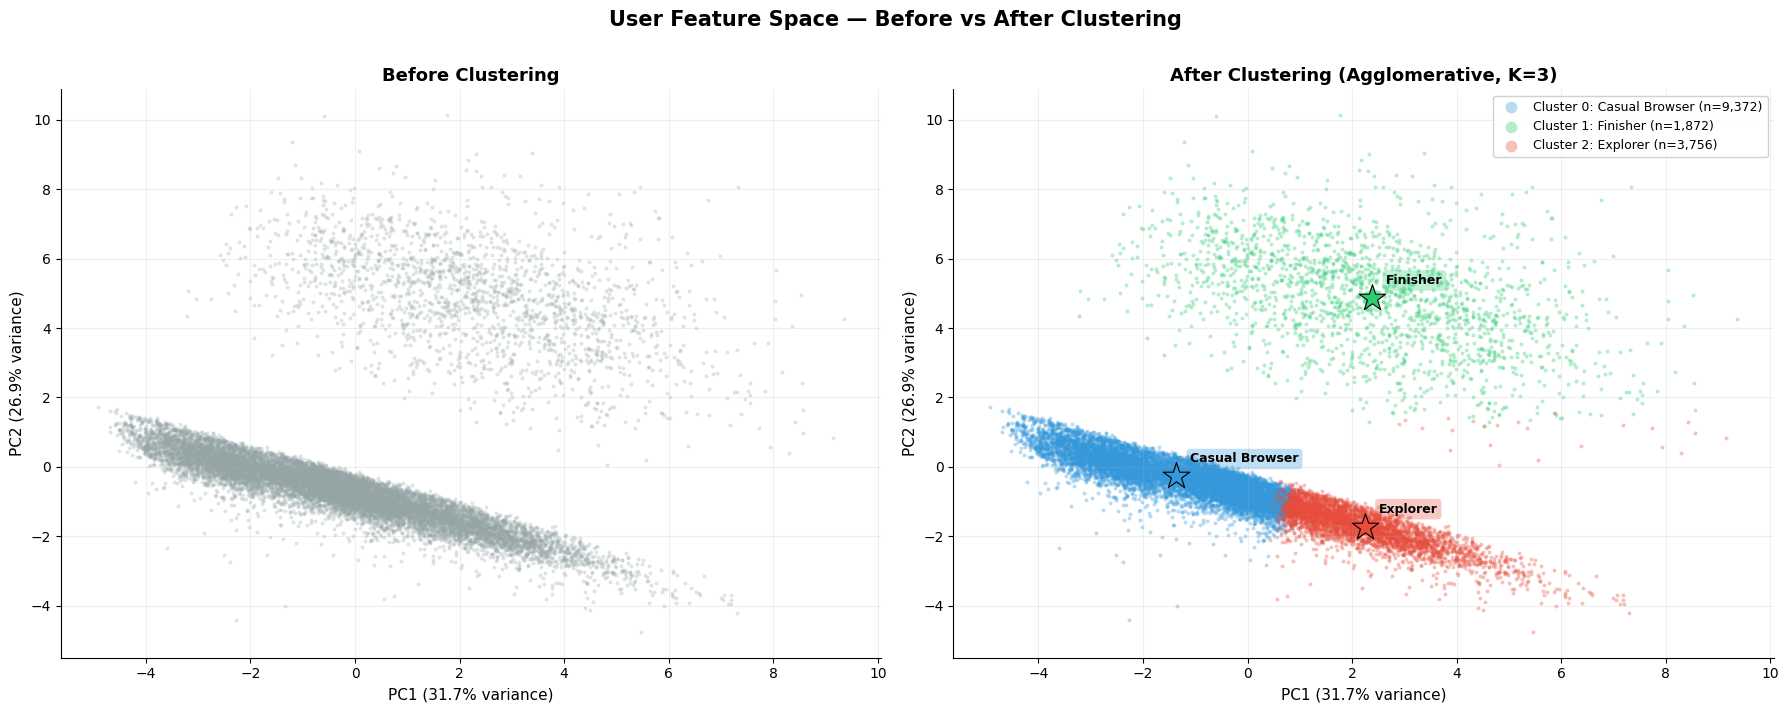

Saved: clustering_scatter.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- Reduce to 2D via PCA ---
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

explained = pca.explained_variance_ratio_
print(f"PCA variance explained: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, Total={sum(explained):.1%}")

# --- Color + label map ---
archetype_colors = {
    0: '#3498db',   # Casual Browser → blue
    1: '#2ecc71',   # Finisher       → green
    2: '#e74c3c',   # Explorer       → red
}
archetype_labels = {
    0: 'Casual Browser',
    1: 'Finisher',
    2: 'Explorer'
}

cluster_labels = cluster_users['cluster'].values

# Compute centroids in scaled space (moved from cell PcOmFXmCZMi8)
cluster_centroids = np.array([
    X[cluster_users['cluster'].values == k].mean(axis=0)
    for k in range(len(archetype_labels)) # Use len(archetype_labels) to get the number of clusters
])

# --- Sample for plot readability (plotting 149k points is slow) ---
PLOT_SAMPLE = 15000
np.random.seed(42)
plot_idx = np.random.choice(len(X_2d), PLOT_SAMPLE, replace=False)

X_plot          = X_2d[plot_idx]
cluster_plot    = cluster_labels[plot_idx]

# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('User Feature Space — Before vs After Clustering',
             fontsize=15, fontweight='bold', y=1.01)

# --- Plot 1: No clustering (all same color) ---
axes[0].scatter(
    X_plot[:, 0], X_plot[:, 1],
    c='#95a5a6', alpha=0.3, s=8, linewidths=0
)
axes[0].set_title('Before Clustering', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained[0]:.1%} variance)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({explained[1]:.1%} variance)', fontsize=11)
axes[0].grid(True, alpha=0.2)
axes[0].spines[['top', 'right']].set_visible(False)

# --- Plot 2: With clustering colors + labels ---
for cluster_id, label in archetype_labels.items():
    mask = cluster_plot == cluster_id
    axes[1].scatter(
        X_plot[mask, 0], X_plot[mask, 1],
        c=archetype_colors[cluster_id],
        label=f'Cluster {cluster_id}: {label} (n={mask.sum():,})',
        alpha=0.35, s=8, linewidths=0
    )

# Plot centroids
centroids_2d = pca.transform(cluster_centroids)
for cluster_id, label in archetype_labels.items():
    axes[1].scatter(
        centroids_2d[cluster_id, 0], centroids_2d[cluster_id, 1],
        c=archetype_colors[cluster_id],
        marker='*', s=400, edgecolors='black', linewidths=0.8,
        zorder=5
    )
    axes[1].annotate(
        label,
        xy=(centroids_2d[cluster_id, 0], centroids_2d[cluster_id, 1]),
        xytext=(10, 10), textcoords='offset points',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor=archetype_colors[cluster_id],
                  alpha=0.3, edgecolor='none')
    )

axes[1].set_title('After Clustering (Agglomerative, K=3)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({explained[0]:.1%} variance)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({explained[1]:.1%} variance)', fontsize=11)
axes[1].legend(loc='upper right', fontsize=9,
               markerscale=3, framealpha=0.9)
axes[1].grid(True, alpha=0.2)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('clustering_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: clustering_scatter.png")

##assign cluster lables and usrs

In [ ]:
archetype_map = {0: 'casual_browser',1: 'finisher',2: 'explorer'}
cluster_users['archetype'] = cluster_users['cluster'].map(archetype_map)

print(cluster_users['archetype'].value_counts())

# Compute centroids in scaled space (for nearest neighbor cluster in recs)
cluster_centroids = np.array([X[cluster_users['cluster'].values == k].mean(axis=0) for k in range(3)])

archetype
casual_browser    90520
explorer          35977
finisher          17776
Name: count, dtype: int64


In [ ]:
##with the recommendation of best books for their respective buckets we will also
##inject a few best books of other buckets too inorder to keep balanced growth
##and increase product discovery

##to implement this the nearest neighbours for ach  clusters are as follow

In [ ]:
# Nearest neighbor cluster per cluster
from sklearn.metrics import pairwise_distances
centroid_distances = pairwise_distances(cluster_centroids)
np.fill_diagonal(centroid_distances, np.inf)  # ignore self

nearest_cluster = {
    k: int(np.argmin(centroid_distances[k]))
    for k in range(3)
}
print("Nearest cluster map:", nearest_cluster)

Nearest cluster map: {0: 2, 1: 0, 2: 0}


In [ ]:
#however got that Finshers are closely related to browsers but
#the domain knowlege gives us a better understanding that
#0: 1,  # Casual Browser needs to push towards  Finnishers
### comperatively new users o platform which ideally should convert to finishers
### hence pushed towards finishers


#1: 2,  # Finisher needs to push towards Explorer
###finishers are my trustworhty pool of users
###so we can use them as anchor to pull up the scores of books those belong to
###Explorer bucket, so that the explorers get quality books and their energy
###can be channelised to get more visibility for the given read worthy book n
###explorer can be converted to finishers



#2: 0   # Explorer needs to push towards Casual Browser
###cannot directly recommend books from finishers as they can pollute and weakn the strength of good books
###hence first their book hopping energy needs to be channelised into lower exploration
###making ideal candidate to push books of casual reader bucket

#book popularity

In [ ]:
# --- Global popularity (for cold users Section 2a) ---
book_popularity = (
    user_book_reads
    .groupby('book_id')
    .agg(
        total_reads     = ('user_id', 'count'),
        total_completes = ('status', lambda x: (x == 'completed').sum())
    )
    .reset_index()
)

# Weighted score: completions count 2x
book_popularity['popularity_score'] = (
    book_popularity['total_reads'] * 1 +
    book_popularity['total_completes'] * 2
)

# --- Cluster-level popularity ---
# Join cluster assignment back to user_book_reads
cluster_user_reads = user_book_reads.merge(
    cluster_users[['user_id', 'cluster', 'archetype']],
    on='user_id', how='inner'
)

cluster_book_popularity = (
    cluster_user_reads
    .groupby(['cluster', 'book_id'])
    .agg(
        cluster_reads     = ('user_id', 'count'),
        cluster_completes = ('status', lambda x: (x == 'completed').sum())
    )
    .reset_index()
)

cluster_book_popularity['cluster_popularity_score'] = (
    cluster_book_popularity['cluster_reads'] * 1 +
    cluster_book_popularity['cluster_completes'] * 2
)

print("Global book popularity shape:", book_popularity.shape)
print(book_popularity.sort_values('popularity_score', ascending=False).head(5))

print("\nCluster book popularity shape:", cluster_book_popularity.shape)
print(cluster_book_popularity.sort_values('cluster_popularity_score', ascending=False).head(5))

Global book popularity shape: (9575, 4)
      book_id  total_reads  total_completes  popularity_score
6053   672233         1161                0              1161
5464   615276          966                0               966
6986   760434          942                0               942
6945   756944          916                0               916
3113   395485          839                0               839

Cluster book popularity shape: (26817, 5)
       cluster  book_id  cluster_reads  cluster_completes  \
17777        1   969659            229                229   
17524        1   945411            226                226   
16722        1   869989            225                225   
9480         1   183335            218                218   
12140        1   436272            214                214   

       cluster_popularity_score  
17777                       687  
17524                       678  
16722                       675  
9480                        654  
12140   

In [ ]:
# For Section 2b: add affinity bonus to cluster popularity score
# Book's tags → match against user's tag affinity scores

# Build user-tag affinity lookup
user_tag_affinity_lookup = (
    user_tag_affinity.set_index(['user_id', 'tag'])['affinity_score']
    .to_dict()
)

# Book tag list (cat1..cat4, excluding Unknown)
book_tags_df = book_meta[['book_id', 'book_cat1', 'book_cat2',
                           'book_cat3', 'book_cat4']].copy()

def get_book_affinity(user_id, book_id, book_tags_df, lookup):
    row = book_tags_df[book_tags_df['book_id'] == book_id]
    if row.empty:
        return 0.0
    tags = [
        row.iloc[0][f'book_cat{i}']
        for i in range(1, 5)
        if row.iloc[0][f'book_cat{i}'] != 'Unknown'
    ]
    return sum(lookup.get((user_id, t), 0.0) for t in tags)

# Pre-build book_id → tags dict for fast lookup
book_tags_dict = {
    row['book_id']: [
        row[f'book_cat{i}']
        for i in range(1, 5)
        if row[f'book_cat{i}'] != 'Unknown'
    ]
    for _, row in book_meta.iterrows()
}

# Vectorized affinity score for a user against a list of book_ids
def get_affinity_scores_for_user(user_id, book_ids):
    scores = []
    for bid in book_ids:
        tags = book_tags_dict.get(bid, [])
        score = sum(user_tag_affinity_lookup.get((user_id, t), 0.0) for t in tags)
        scores.append(score)
    return scores

print("Affinity lookup built. Keys sample:")
print(list(user_tag_affinity_lookup.keys())[:5])

Affinity lookup built. Keys sample:
[('user_0000013', 'Adventure'), ('user_0000013', 'Crime'), ('user_0000013', 'Fantasy'), ('user_0000013', 'Graphic Novel'), ('user_0000013', 'Historical Fiction')]


#recommendation for cold users

In [ ]:
TOP_N = 10

# Books already touched per user
user_touched_books = (
    user_book_reads[user_book_reads['read_pct'] > 0]
    .groupby('user_id')['book_id']
    .apply(set)
    .to_dict()
)

# Sorted global popular books
global_top_books = (
    book_popularity
    .sort_values('popularity_score', ascending=False)
    ['book_id'].tolist()
)

def get_cold_recommendations(user_id, top_n=TOP_N):
    touched = user_touched_books.get(user_id, set())
    recs = [b for b in global_top_books if b not in touched]
    return recs[:top_n]

# Test
sample_cold_user = cold_users['user_id'].iloc[0]
print(f"Cold recs for {sample_cold_user}:")
print(get_cold_recommendations(sample_cold_user))

Cold recs for user_0009857:
[672233, 615276, 760434, 756944, 395485, 791274, 181288, 682667, 316800, 478798]


#recommendation for existing sers

In [ ]:
def get_cluster_recommendations(user_id, top_n=TOP_N):
    # Get user's cluster
    user_row = cluster_users[cluster_users['user_id'] == user_id]
    if user_row.empty:
        return get_cold_recommendations(user_id, top_n)

    user_cluster = int(user_row['cluster'].iloc[0])
    neighbor_cluster = nearest_cluster[user_cluster]
    touched = user_touched_books.get(user_id, set())

    def score_books(cluster_id, n):
        candidates = (
            cluster_book_popularity[
                cluster_book_popularity['cluster'] == cluster_id
            ]
            .copy()
        )
        candidates = candidates[~candidates['book_id'].isin(touched)]

        # Add affinity bonus
        candidates['affinity_bonus'] = get_affinity_scores_for_user(
            user_id, candidates['book_id'].tolist()
        )
        candidates['final_score'] = (
            candidates['cluster_popularity_score'] + candidates['affinity_bonus']
        )
        return (
            candidates
            .sort_values('final_score', ascending=False)
            ['book_id'].tolist()[:n]
        )

    # 70% from own cluster, 30% from neighbor
    own_n      = int(top_n * 0.7)
    neighbor_n = top_n - own_n

    own_recs      = score_books(user_cluster,    own_n)
    neighbor_recs = score_books(neighbor_cluster, neighbor_n)

    return own_recs + neighbor_recs

# Test
sample_cluster_user = cluster_users['user_id'].iloc[0]
print(f"Cluster recs for {sample_cluster_user}:")
print(get_cluster_recommendations(sample_cluster_user))

Cluster recs for user_0000013:
[672233, 615276, 756944, 760434, 395485, 181288, 319242, 672233, 760434, 615276]


#final output

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# --- Pre-normalize cluster_popularity_score and affinity to same scale ---
# We'll do this inside the scoring function using min-max on candidates

def score_books_fixed(user_id, cluster_id, touched, n):
    candidates = (
        cluster_book_popularity[
            cluster_book_popularity['cluster'] == cluster_id
        ]
        .copy()
    )
    candidates = candidates[~candidates['book_id'].isin(touched)]
    if candidates.empty:
        return []

    # Affinity bonus
    candidates['affinity_bonus'] = get_affinity_scores_for_user(
        user_id, candidates['book_id'].tolist()
    )

    # Normalize both scores to [0, 1] before combining
    for col in ['cluster_popularity_score', 'affinity_bonus']:
        col_min = candidates[col].min()
        col_max = candidates[col].max()
        denom   = col_max - col_min if col_max != col_min else 1
        candidates[f'{col}_norm'] = (candidates[col] - col_min) / denom

    # Final score: 60% popularity + 40% affinity
    candidates['final_score'] = (
        candidates['cluster_popularity_score_norm'] * 0.6 +
        candidates['affinity_bonus_norm']           * 0.4
    )

    return (
        candidates
        .sort_values('final_score', ascending=False)
        ['book_id'].tolist()[:n]
    )


def get_cluster_recommendations_v2(user_id, top_n=TOP_N):
    user_row = cluster_users[cluster_users['user_id'] == user_id]
    if user_row.empty:
        return get_cold_recommendations(user_id, top_n)

    user_cluster    = int(user_row['cluster'].iloc[0])
    neighbor_cluster = nearest_cluster[user_cluster]
    touched          = user_touched_books.get(user_id, set())

    own_n      = int(top_n * 0.7)   # 7 from own cluster
    neighbor_n = top_n - own_n       # 3 from neighbor

    own_recs      = score_books_fixed(user_id, user_cluster,    touched, own_n)

    # Exclude own_recs from neighbor pool to prevent duplicates
    touched_extended = touched | set(own_recs)
    neighbor_recs = score_books_fixed(user_id, neighbor_cluster, touched_extended, neighbor_n)

    # Final dedup preserving order (safety net)
    seen, final = set(), []
    for b in own_recs + neighbor_recs:
        if b not in seen:
            seen.add(b)
            final.append(b)

    return final[:top_n]


def get_recommendations_v2(user_id):
    continue_reading  = continue_reading_dict.get(user_id, [])
    is_cold = user_id in cold_users['user_id'].values

    you_may_also_like = (
        get_cold_recommendations(user_id)
        if is_cold else
        get_cluster_recommendations_v2(user_id)
    )

    return {
        'user_id'          : user_id,
        'continue_reading' : continue_reading,
        'you_may_also_like': you_may_also_like
    }

# Test same users
for uid in [sample_cold_user, sample_cluster_user]:
    result = get_recommendations_v2(uid)
    print(f"\n{'='*50}")
    print(f"User     : {result['user_id']}")
    print(f"Continue : {result['continue_reading']}")
    print(f"You May  : {result['you_may_also_like']}")
    print(f"Unique?  : {len(result['you_may_also_like']) == len(set(result['you_may_also_like']))}")


User     : user_0009857
Continue : [180385]
You May  : [672233, 615276, 760434, 756944, 395485, 791274, 181288, 682667, 316800, 478798]
Unique?  : True

User     : user_0000013
Continue : [469844, 976042]
You May  : [672233, 181288, 999876, 756944, 682667, 615276, 116470, 689448, 760434, 137728]
Unique?  : True
